In [ ]:
from utils import load_data, split_data, preprocess
from utils import preprocess_v1, preprocess_v2, preprocess_v3, preprocess_v4
from utils import compare_errors, plot_error_matrix, print_error_examples
from utils import max_features_svm, prepare_plot_data, analyze_common_cases

import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Times New Roman"

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [4]:
df, X, y = load_data()
X_train, X_val, X_test, y_train, y_val, y_test = split_data(X, y)

print("Liczba przykładów:")
print(f"  treningowych   {len(y_train):,}")
print(f"  walidacyjnych  {len(y_val):,}")
print(f"  testowych      {len(y_test):,}")

Liczba przykładów:
  treningowych   36,876
  walidacyjnych  7,902
  testowych      7,903


In [5]:
baseline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("log_reg", LogisticRegression(max_iter=1_000))
])

In [6]:
X_train_base = X_train.apply(preprocess)
X_val_base = X_val.apply(preprocess)
X_test_base = X_test.apply(preprocess)

In [7]:
X_train_v1 = X_train.apply(preprocess_v1)
X_val_v1 = X_val.apply(preprocess_v1)
X_test_v1 = X_test.apply(preprocess_v1)

In [8]:
X_train_v2 = X_train.apply(preprocess_v2)
X_val_v2 = X_val.apply(preprocess_v2)
X_test_v2 = X_test.apply(preprocess_v2)

In [9]:
X_train_v3 = X_train.apply(preprocess_v3)
X_val_v3 = X_val.apply(preprocess_v3)
X_test_v3 = X_test.apply(preprocess_v3)

In [10]:
X_train_v4 = X_train.apply(preprocess_v4)
X_val_v4 = X_val.apply(preprocess_v4)
X_test_v4 = X_test.apply(preprocess_v4)

### Eksperyment 2.1: mocniejszy model
Użycie `LinearSVC` zamiast `LogisticRegression`.

In [11]:
svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", LinearSVC())
])

In [12]:
svm_pipeline.fit(X_train_base, y_train)
y_val_pred_svm_base = svm_pipeline.predict(X_val_base)
f1_macro_svm_base = f1_score(y_val, y_val_pred_svm_base, average='macro')

print(classification_report(y_val, y_val_pred_svm_base))
print(f"F1 macro: {f1_macro_svm_base:.2f}")

                      precision    recall  f1-score   support

             Anxiety       0.81      0.78      0.79       576
             Bipolar       0.83      0.69      0.75       416
          Depression       0.71      0.72      0.71      2311
              Normal       0.88      0.94      0.91      2451
Personality disorder       0.83      0.60      0.70       162
              Stress       0.66      0.51      0.57       388
            Suicidal       0.67      0.67      0.67      1598

            accuracy                           0.77      7902
           macro avg       0.77      0.70      0.73      7902
        weighted avg       0.77      0.77      0.77      7902

F1 macro: 0.73


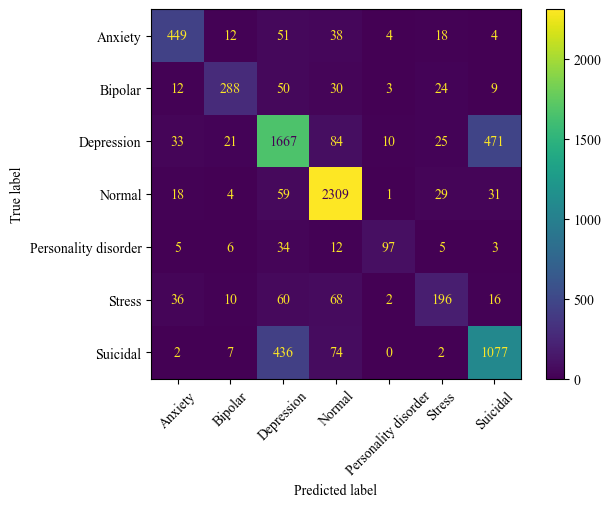

In [13]:
cm_svm = confusion_matrix(y_val, y_val_pred_svm_base)
ConfusionMatrixDisplay.from_predictions(
    y_val, y_val_pred_svm_base,
    xticks_rotation=45)

In [14]:
print("Baseline:")
f1_scores_svm_base = max_features_svm(X_train_base, X_val_base, y_train, y_val)

Baseline:
max_features=500, F1 macro: 0.61
max_features=1000, F1 macro: 0.67
max_features=1500, F1 macro: 0.69
max_features=2000, F1 macro: 0.70
max_features=2500, F1 macro: 0.71
max_features=3000, F1 macro: 0.71
max_features=3500, F1 macro: 0.72
max_features=4000, F1 macro: 0.72
max_features=4500, F1 macro: 0.72
max_features=5000, F1 macro: 0.73
max_features=None, F1 macro: 0.73


In [15]:
print("Preprocessing v1:")
f1_scores_svm_v1 = max_features_svm(X_train_v1, X_val_v1, y_train, y_val)

Preprocessing v1:
max_features=500, F1 macro: 0.58
max_features=1000, F1 macro: 0.65
max_features=1500, F1 macro: 0.68
max_features=2000, F1 macro: 0.67
max_features=2500, F1 macro: 0.68
max_features=3000, F1 macro: 0.69
max_features=3500, F1 macro: 0.70
max_features=4000, F1 macro: 0.70
max_features=4500, F1 macro: 0.70
max_features=5000, F1 macro: 0.70
max_features=None, F1 macro: 0.71


In [16]:
print("Preprocessing v2:")
f1_scores_svm_v2 = max_features_svm(X_train_v2, X_val_v2, y_train, y_val)

Preprocessing v2:


max_features=500, F1 macro: 0.58
max_features=1000, F1 macro: 0.65
max_features=1500, F1 macro: 0.67
max_features=2000, F1 macro: 0.67
max_features=2500, F1 macro: 0.67
max_features=3000, F1 macro: 0.68
max_features=3500, F1 macro: 0.68
max_features=4000, F1 macro: 0.69
max_features=4500, F1 macro: 0.69
max_features=5000, F1 macro: 0.68
max_features=None, F1 macro: 0.69


In [17]:
print("Preprocessing v3:")
f1_scores_svm_v3 = max_features_svm(X_train_v3, X_val_v3, y_train, y_val)

Preprocessing v3:
max_features=500, F1 macro: 0.59
max_features=1000, F1 macro: 0.66
max_features=1500, F1 macro: 0.67
max_features=2000, F1 macro: 0.68
max_features=2500, F1 macro: 0.68
max_features=3000, F1 macro: 0.69
max_features=3500, F1 macro: 0.69
max_features=4000, F1 macro: 0.70
max_features=4500, F1 macro: 0.70
max_features=5000, F1 macro: 0.70
max_features=None, F1 macro: 0.70


In [18]:
print("Preprocessing v4:")
f1_scores_svm_v4 = max_features_svm(X_train_v4, X_val_v4, y_train, y_val)

Preprocessing v4:
max_features=500, F1 macro: 0.58
max_features=1000, F1 macro: 0.66
max_features=1500, F1 macro: 0.67
max_features=2000, F1 macro: 0.67
max_features=2500, F1 macro: 0.68
max_features=3000, F1 macro: 0.68
max_features=3500, F1 macro: 0.68
max_features=4000, F1 macro: 0.69
max_features=4500, F1 macro: 0.69
max_features=5000, F1 macro: 0.69
max_features=None, F1 macro: 0.69


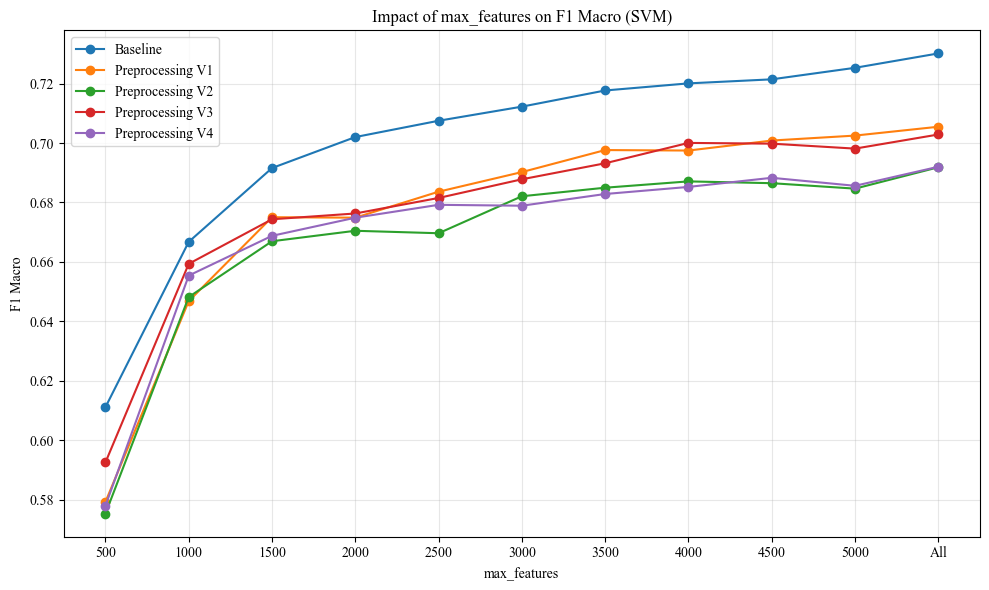

In [19]:
# wizualizacja wpływu max_features na F1 macro (model=SVM)
x_base, y_base = prepare_plot_data(f1_scores_svm_base)
x_v1, y_v1 = prepare_plot_data(f1_scores_svm_v1)
x_v2, y_v2 = prepare_plot_data(f1_scores_svm_v2)
x_v3, y_v3 = prepare_plot_data(f1_scores_svm_v3)
x_v4, y_v4 = prepare_plot_data(f1_scores_svm_v4)

plt.figure(figsize=(10, 6))
plt.plot(x_base, y_base, marker='o', label='Baseline')
plt.plot(x_v1, y_v1, marker='o', label='Preprocessing V1')
plt.plot(x_v2, y_v2, marker='o', label='Preprocessing V2')
plt.plot(x_v3, y_v3, marker='o', label='Preprocessing V3')
plt.plot(x_v4, y_v4, marker='o', label='Preprocessing V4')

plt.title("Impact of max_features on F1 Macro (SVM)")
plt.xlabel("max_features")
plt.ylabel("F1 Macro")

plt.xticks(
    [500,1000,1500,2000,2500,3000,3500,4000,4500,5000,5500],
    ['500','1000','1500','2000','2500','3000','3500','4000','4500','5000','All']
)

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

### Eksperyment 2.2: szerszy kontekst (bigramy)

In [20]:
# pipeline dla TF-IDF z użyciem bigramów
bi_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2))),
    ("log_reg", LogisticRegression(max_iter=1_000))
])

In [21]:
bi_pipeline.fit(X_train_base, y_train)
y_val_pred_bi = bi_pipeline.predict(X_val_base)
f1_macro_bi = f1_score(y_val, y_val_pred_bi, average='macro')

print(classification_report(y_val, y_val_pred_bi))
print(f"F1 macro: {f1_macro_bi:.2f}")

                      precision    recall  f1-score   support

             Anxiety       0.82      0.69      0.75       576
             Bipolar       0.87      0.57      0.69       416
          Depression       0.67      0.76      0.71      2311
              Normal       0.85      0.95      0.90      2451
Personality disorder       0.93      0.32      0.48       162
              Stress       0.68      0.36      0.47       388
            Suicidal       0.71      0.68      0.69      1598

            accuracy                           0.76      7902
           macro avg       0.79      0.62      0.67      7902
        weighted avg       0.76      0.76      0.75      7902

F1 macro: 0.67


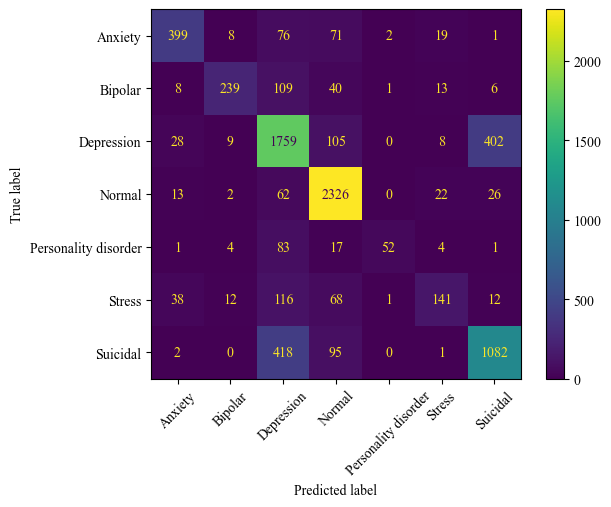

In [22]:
cm_bi = confusion_matrix(y_val, y_val_pred_bi)
ConfusionMatrixDisplay.from_predictions(
    y_val, y_val_pred_bi,
    xticks_rotation=45)

In [23]:
# pipeline dla TF-IDF z użyciem bigramów i klasyfikatora SVM
bi_svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2))),
    ("clf", LinearSVC())
])

In [24]:
bi_svm_pipeline.fit(X_train_base, y_train)
y_val_pred_bi_svm = bi_svm_pipeline.predict(X_val_base)
f1_macro_bi_svm = f1_score(y_val, y_val_pred_bi_svm, average='macro')

print(classification_report(y_val, y_val_pred_bi_svm))
print(f"F1 macro: {f1_macro_bi_svm:.2f}")

                      precision    recall  f1-score   support

             Anxiety       0.81      0.79      0.80       576
             Bipolar       0.87      0.72      0.79       416
          Depression       0.71      0.74      0.72      2311
              Normal       0.90      0.95      0.92      2451
Personality disorder       0.92      0.52      0.66       162
              Stress       0.71      0.48      0.57       388
            Suicidal       0.67      0.69      0.68      1598

            accuracy                           0.78      7902
           macro avg       0.80      0.70      0.74      7902
        weighted avg       0.78      0.78      0.78      7902

F1 macro: 0.74


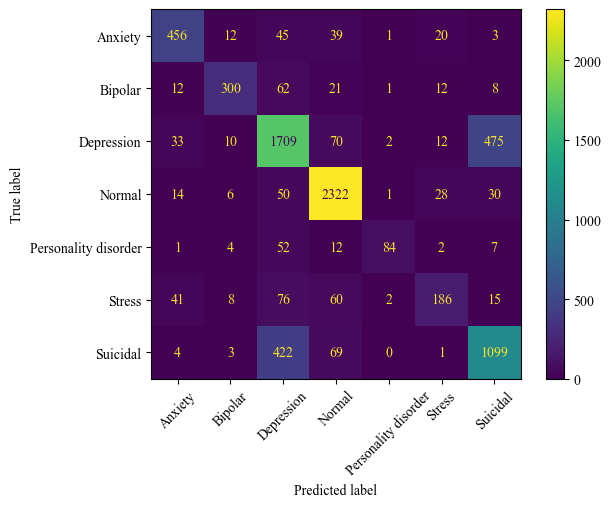

In [25]:
cm_bi_svm = confusion_matrix(y_val, y_val_pred_bi_svm)
ConfusionMatrixDisplay.from_predictions(
    y_val, y_val_pred_bi_svm,
    xticks_rotation=45)

### Eksperyment 2.3: szerszy kontekst (trigramy)

In [26]:
# pipeline dla TF-IDF z użyciem trigramów
tri_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 3))),
    ("log_reg", LogisticRegression(max_iter=1_000))
])

In [27]:
tri_pipeline.fit(X_train_base, y_train)
y_val_pred_tri = tri_pipeline.predict(X_val_base)
f1_macro_tri = f1_score(y_val, y_val_pred_tri, average='macro')

print(classification_report(y_val, y_val_pred_tri))
print(f"F1 macro: {f1_macro_tri:.2f}")

                      precision    recall  f1-score   support

             Anxiety       0.82      0.69      0.75       576
             Bipolar       0.85      0.57      0.68       416
          Depression       0.63      0.78      0.70      2311
              Normal       0.88      0.92      0.90      2451
Personality disorder       0.97      0.19      0.32       162
              Stress       0.69      0.31      0.43       388
            Suicidal       0.71      0.66      0.69      1598

            accuracy                           0.75      7902
           macro avg       0.79      0.59      0.64      7902
        weighted avg       0.76      0.75      0.74      7902

F1 macro: 0.64


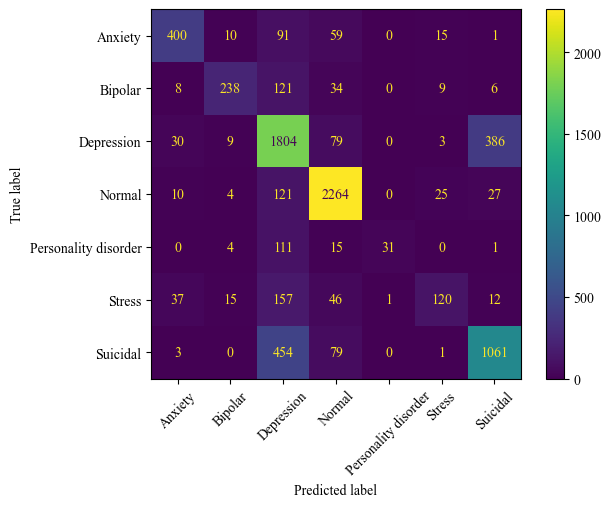

In [28]:
cm_tri = confusion_matrix(y_val, y_val_pred_tri)
ConfusionMatrixDisplay.from_predictions(
    y_val, y_val_pred_tri,
    xticks_rotation=45)

In [29]:
# pipeline dla TF-IDF z użyciem trigramów i klasyfikatora SVM
tri_svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 3))),
    ("clf", LinearSVC())
])

In [30]:
tri_svm_pipeline.fit(X_train_base, y_train)
y_val_pred_tri_svm = tri_svm_pipeline.predict(X_val_base)
f1_macro_tri_svm = f1_score(y_val, y_val_pred_tri_svm, average='macro')

print(classification_report(y_val, y_val_pred_tri_svm))
print(f"F1 macro: {f1_macro_tri_svm:.2f}")

                      precision    recall  f1-score   support

             Anxiety       0.80      0.82      0.81       576
             Bipolar       0.84      0.71      0.77       416
          Depression       0.69      0.76      0.73      2311
              Normal       0.92      0.93      0.93      2451
Personality disorder       0.92      0.48      0.63       162
              Stress       0.74      0.47      0.58       388
            Suicidal       0.69      0.69      0.69      1598

            accuracy                           0.78      7902
           macro avg       0.80      0.69      0.73      7902
        weighted avg       0.79      0.78      0.78      7902

F1 macro: 0.73


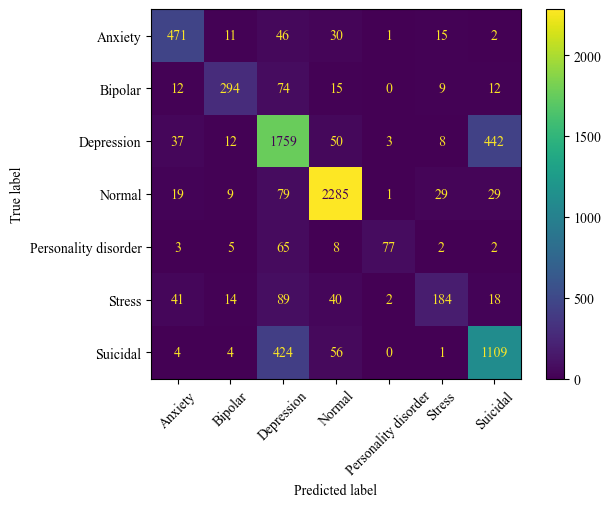

In [31]:
cm_tri_svm = confusion_matrix(y_val, y_val_pred_tri_svm)
ConfusionMatrixDisplay.from_predictions(
    y_val, y_val_pred_tri_svm,
    xticks_rotation=45)

### Analiza błędów

In [32]:
baseline.fit(X_train_base, y_train)
y_val_pred = baseline.predict(X_val_base)

In [33]:
predictions = {
    "baseline" : y_val_pred,
    "svm" : y_val_pred_svm_base,
    "bi" : y_val_pred_bi,
    "tri" : y_val_pred_tri,
    "svm_bi" : y_val_pred_bi_svm,
    "svm_tri" : y_val_pred_tri_svm,
}

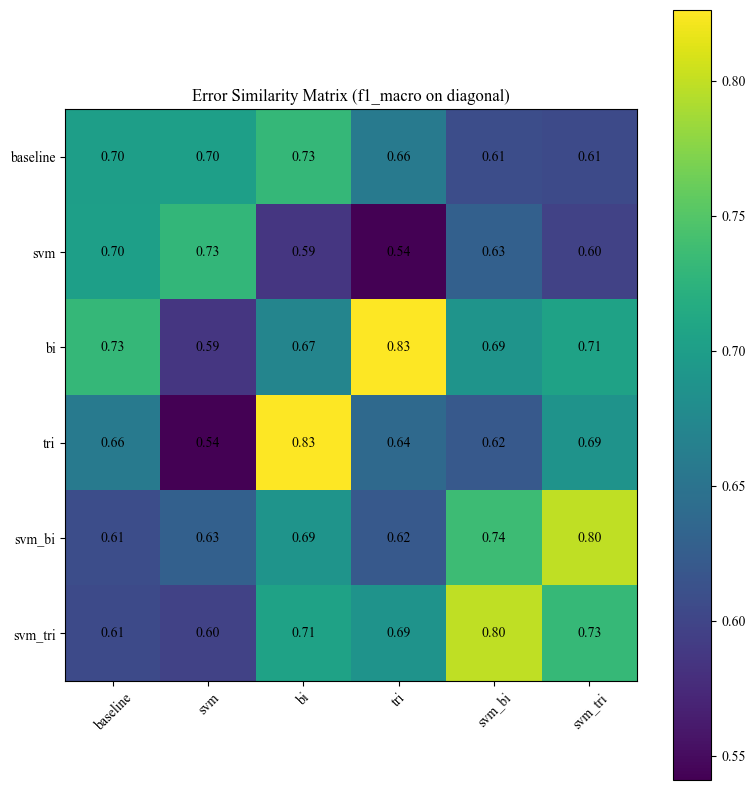

In [34]:
results, metrics = compare_errors(predictions, y_val)
plot_error_matrix(results, metrics, metric='f1_macro')

In [39]:
print_error_examples(
    results,
    X_val_base,
    y_val,
    predictions,
    n_examples=3
)


baseline vs svm

--- Shared errors ---

ID: 8
TEXT: can’t take it anymore today has been one of the worst days in a long time. out of so many countless times i have wanted to just give up and end it, i kept going. thought i was getting a loan so i could get out of debt and actually have some money to get things i desperately need since i haven’t work
TRUE: Bipolar
baseline: Depression
svm: Stress

ID: 11
TEXT: i always make mistakes, and bad decisions. i have no skills or talents. i have no accomplishments. i feel like a useless person. my parents make me feel stupid, for every mistake that i make. i feel like i will never be where i want to, because i cannot do simple thing. i never feel like i am good e
TRUE: Suicidal
baseline: Depression
svm: Depression

ID: 17
TEXT: hey guys, i am currently in the progress of wring a research plan for my internship. i am doing a project on the effects of scaring trials on eurasian cranes on agricultural fields. however, english is not my native la

In [36]:
analysis = analyze_common_cases(
    predictions,
    y_val,
    X_val_base,
    k_examples=20
)

ALL MODELS CORRECT

Count: 5186

Class distribution:
Normal                  2189
Depression              1443
Suicidal                 850
Anxiety                  360
Bipolar                  213
Stress                   101
Personality disorder      30
dtype: int64

Examples:

----------------------------------------
ID: 0
TRUE: Normal
TEXT:
@marthastewart proof?

----------------------------------------
ID: 1
TRUE: Depression
TEXT:
when i get told i am a good guy it sometimes drives me near to tears. i have been told how nice i am. how funny i am. how dependable. i have been told many times by different people these things so it must be true right? but i guess i am not good enough. if i was it would not be so hard to find and keep people in my life. i know it sounds self serving and all pity party but its how i feel and the thoughts in my head. i realize and understand that i am not a priority to anyone else. i just wish i

----------------------------------------
ID: 2
TRUE: Norma